# Construction-Related Incidents Analysis

In [1]:
import pandas as pd
import seaborn as sea

sea.set_theme(
    style='darkgrid',
    rc={
        'figure.facecolor': 'black',
        'axes.facecolor': 'black',
        'text.color': 'white',
        'axes.labelcolor': 'white',
        'xtick.color': 'white',
        'ytick.color': 'white'
    }
)

accent_color = '#4DABF7'

In [2]:
raw_data = pd.read_csv('Construction-Related_Incidents_20260713.csv')
raw_data.head()

,BIN,Accident Report ID,Incident Date,Record Type Description,Check2 Description,Fatality,Injury,House Number,Street Name,Borough,Block,Lot,Postcode,Latitude,Longitude,Community Board,Council District,BBL,Census Tract (2020),Neighborhood Tabulation Area (NTA) (2020)
0,1034211.0,43977,11/19/2024,Incident,Other Construction Related,0,0,520,5 AVENUE,Manhattan,1259.0,35.0,10036.0,40.754421,-73.980213,105.0,4.0,1.012590e+09,96.0,MN0502
1,1060875.0,43984,11/21/2024,Incident,Other Construction Related,0,0,2855,FREDERICK DOUGLAS BOULEVARD,Manhattan,2046.0,63.0,10039.0,40.827410,-73.938587,110.0,9.0,1.020460e+09,23502.0,MN1002
2,3124075.0,45118,10/07/2025,Incident,Scaffold/Shoring Installations,0,0,23,OCEAN PARKWAY,Brooklyn,5322.0,4.0,11218.0,40.650467,-73.973610,307.0,40.0,3.053220e+09,50401.0,BK0701
3,1091801.0,44113,12/30/2024,Accident,Mechanical Construction Equipment,0,1,439,WEST 36 STREET,Manhattan,734.0,10.0,10018.0,40.755430,-73.997152,104.0,3.0,1.007340e+09,111.0,MN0401
4,2130685.0,43974,11/14/2024,Accident,Other Construction Related,0,1,221 D,MANIDA STREET,Bronx,2777.0,100.0,10474.0,40.805223,-73.885975,202.0,17.0,2.027770e+09,9302.0,BX0201


## Explore the data

In [3]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1321 entries, 0 to 1320
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   BIN                                        1318 non-null   float64
 1   Accident Report ID                         1321 non-null   int64  
 2   Incident Date                              1321 non-null   str    
 3   Record Type Description                    1321 non-null   str    
 4   Check2 Description                         1320 non-null   str    
 5   Fatality                                   1321 non-null   int64  
 6   Injury                                     1321 non-null   int64  
 7   House Number                               1321 non-null   str    
 8   Street Name                                1321 non-null   str    
 9   Borough                                    1321 non-null   str    
 10  Block                              

In [4]:
raw_data['Check2 Description'].value_counts()

Check2 Description
Worker Fell                          499
Other Construction Related           478
Material Failure (Fell)              145
Mechanical Construction Equipment     97
Scaffold/Shoring Installations        58
Excavation/Soil Work                  43
Name: count, dtype: int64

## Check "Other Construction Related" records

In [5]:
other_construction = raw_data[
    raw_data['Check2 Description'] == 'Other Construction Related'
]

other_construction.head()

,BIN,Accident Report ID,Incident Date,Record Type Description,Check2 Description,Fatality,Injury,House Number,Street Name,Borough,Block,Lot,Postcode,Latitude,Longitude,Community Board,Council District,BBL,Census Tract (2020),Neighborhood Tabulation Area (NTA) (2020)
0,1034211.0,43977,11/19/2024,Incident,Other Construction Related,0,0,520,5 AVENUE,Manhattan,1259.0,35.0,10036.0,40.754421,-73.980213,105.0,4.0,1.012590e+09,96.0,MN0502
1,1060875.0,43984,11/21/2024,Incident,Other Construction Related,0,0,2855,FREDERICK DOUGLAS BOULEVARD,Manhattan,2046.0,63.0,10039.0,40.827410,-73.938587,110.0,9.0,1.020460e+09,23502.0,MN1002
4,2130685.0,43974,11/14/2024,Accident,Other Construction Related,0,1,221 D,MANIDA STREET,Bronx,2777.0,100.0,10474.0,40.805223,-73.885975,202.0,17.0,2.027770e+09,9302.0,BX0201
7,3428561.0,43920,11/04/2024,Accident,Other Construction Related,0,1,1215,FULTON STREET,Brooklyn,1842.0,15.0,11216.0,40.680609,-73.952845,303.0,36.0,3.018420e+09,245.0,BK0301
10,1091788.0,45119,10/08/2025,Accident,Other Construction Related,0,1,255,EAST 39 STREET,Manhattan,920.0,28.0,10016.0,40.748247,-73.974347,106.0,4.0,NaN,88.0,MN0603


In [6]:
other_construction['Borough'].value_counts()

Borough
Manhattan        180
Brooklyn         175
Queens            63
Bronx             51
Staten Island      9
Name: count, dtype: int64

In [7]:
other_construction[['Fatality', 'Injury']].sum()

Fatality      3
Injury      312
dtype: int64

## Injury counts by borough

In [8]:
borough_injuries = raw_data.groupby('Borough')['Injury'].sum().reset_index()

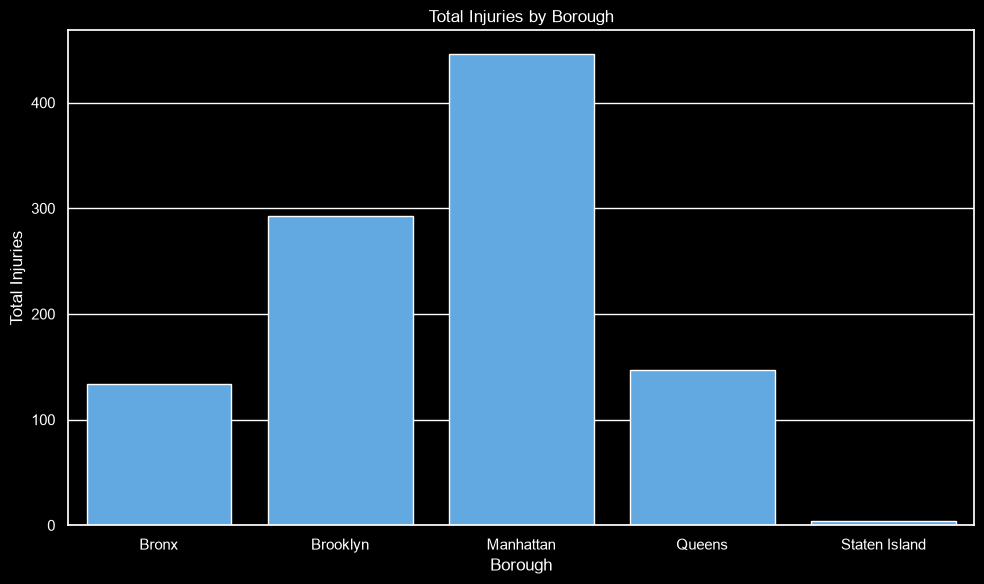

In [9]:
ax = sea.barplot(
    data=borough_injuries,
    x='Borough',
    y='Injury',
    color=accent_color
)
ax.set(
    title='Total Injuries by Borough',
    xlabel='Borough',
    ylabel='Total Injuries'
)
ax.figure.set_size_inches(10, 6)
ax.figure.tight_layout()

## Accident dates

In [10]:
raw_data['Incident Date'] = pd.to_datetime(raw_data['Incident Date'])

In [11]:
raw_data['Month'] = raw_data['Incident Date'].dt.month_name()

In [12]:
accidents = raw_data[
    raw_data['Record Type Description'] == 'Accident'
].copy()

accidents.head()

,BIN,Accident Report ID,Incident Date,Record Type Description,Check2 Description,Fatality,Injury,House Number,Street Name,Borough,...,Lot,Postcode,Latitude,Longitude,Community Board,Council District,BBL,Census Tract (2020),Neighborhood Tabulation Area (NTA) (2020),Month
3,1091801.0,44113,2024-12-30,Accident,Mechanical Construction Equipment,0,1,439,WEST 36 STREET,Manhattan,...,10.0,10018.0,40.755430,-73.997152,104.0,3.0,1.007340e+09,111.0,MN0401,December
4,2130685.0,43974,2024-11-14,Accident,Other Construction Related,0,1,221 D,MANIDA STREET,Bronx,...,100.0,10474.0,40.805223,-73.885975,202.0,17.0,2.027770e+09,9302.0,BX0201,November
5,3429247.0,43925,2024-11-05,Accident,Worker Fell,0,1,487,4 AVENUE,Brooklyn,...,7.0,11215.0,40.668453,-73.990289,306.0,38.0,3.010280e+09,139.0,BK0602,November
6,4855669.0,44747,2025-06-27,Accident,Excavation/Soil Work,0,1,133-45,39 AVENUE,Queens,...,59.0,11354.0,40.759123,-73.834147,407.0,20.0,NaN,871.0,QN0707,June
7,3428561.0,43920,2024-11-04,Accident,Other Construction Related,0,1,1215,FULTON STREET,Brooklyn,...,15.0,11216.0,40.680609,-73.952845,303.0,36.0,3.018420e+09,245.0,BK0301,November


In [13]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

## Total accidents by month

In [14]:
accidents_by_month = accidents.groupby('Month')['Accident Report ID'].count()
accidents_by_month = accidents_by_month[month_order]
accidents_by_month = accidents_by_month.reset_index()
accidents_by_month

,Month,Accident Report ID
0,January,99
1,February,85
2,March,104
3,April,104
4,May,99
5,June,109
6,July,85
7,August,66
8,September,54
9,October,55


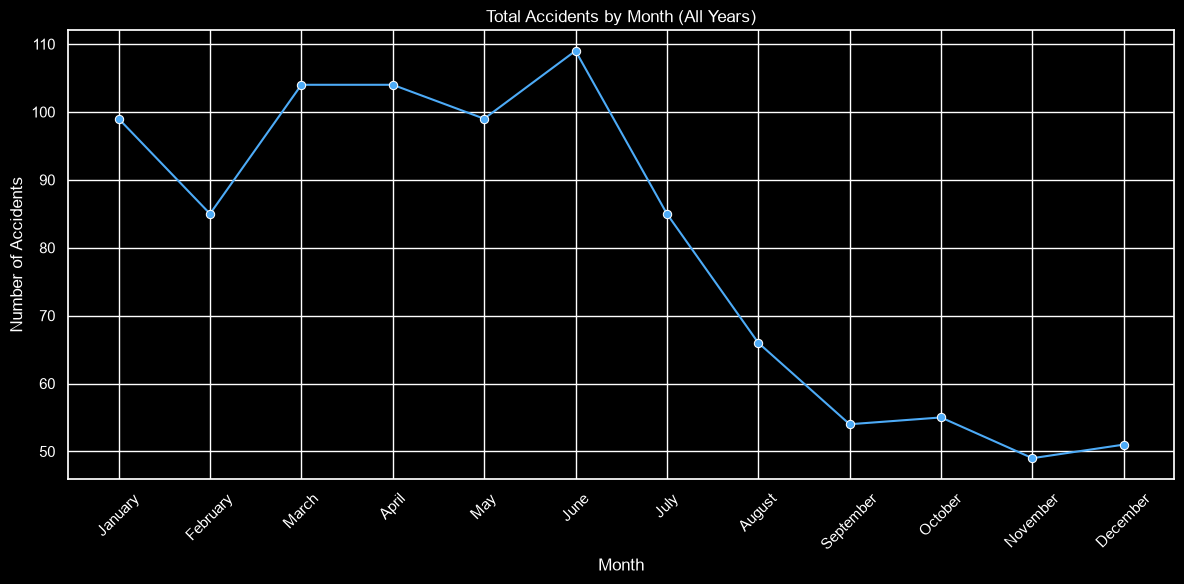

In [15]:
ax = sea.lineplot(
    data=accidents_by_month,
    x='Month',
    y='Accident Report ID',
    marker='o',
    color=accent_color
)
ax.set(
    title='Total Accidents by Month (All Years)',
    xlabel='Month',
    ylabel='Number of Accidents'
)
ax.tick_params(axis='x', rotation=45)
ax.figure.set_size_inches(12, 6)
ax.figure.tight_layout()

## Accident types by month

In [16]:
accident_types = pd.crosstab(
    accidents['Check2 Description'],
    accidents['Month']
)

accident_types = accident_types[month_order]

In [17]:
accident_types.loc['Total'] = accident_types.sum()

accident_types.columns = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

accident_types

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Check2 Description,,,,,,,,,,,,
Excavation/Soil Work,2,2,0,1,1,1,1,2,1,0,0,1
Material Failure (Fell),8,12,18,11,6,8,8,2,5,8,5,5
Mechanical Construction Equipment,11,10,6,7,10,8,2,2,2,4,3,3
Other Construction Related,23,20,31,35,28,37,25,23,16,15,12,17
Scaffold/Shoring Installations,1,1,1,5,1,1,2,2,2,1,1,1
Worker Fell,54,40,48,45,53,54,47,35,28,27,28,24
Total,99,85,104,104,99,109,85,66,54,55,49,51


In [18]:
type_counts = accident_types.drop('Total')
max_count = type_counts.max().max()

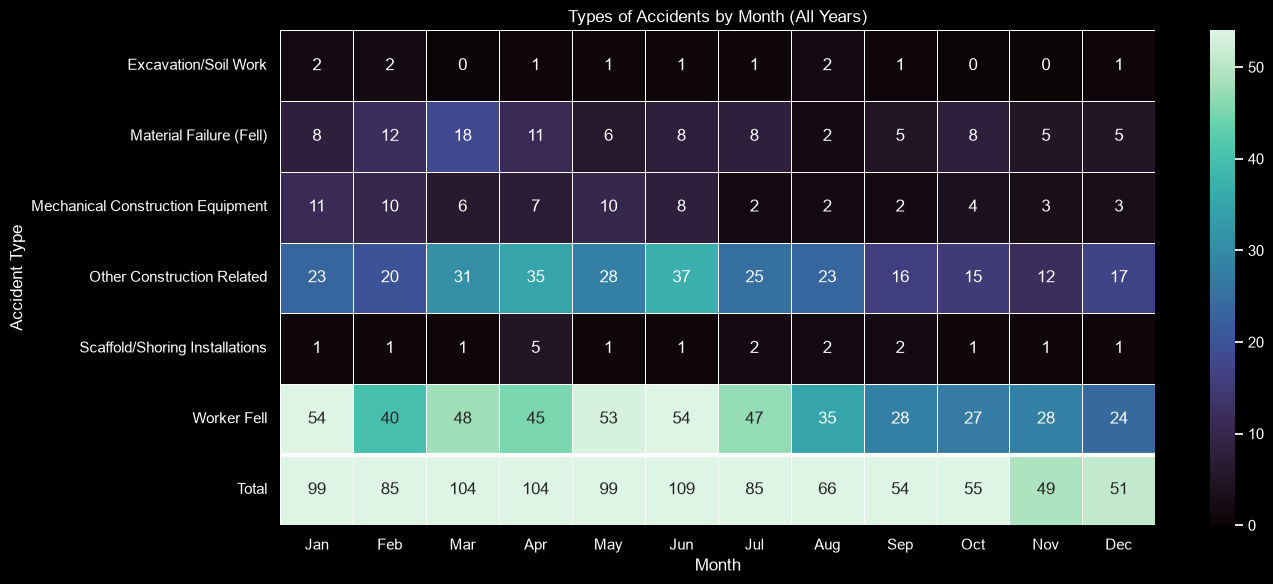

In [19]:
ax = sea.heatmap(
    accident_types,
    annot=True,
    fmt='g',
    cmap='mako',
    vmax=max_count,
    linewidths=0.5
)
ax.hlines(6, 0, 12, colors='white', linewidths=3)
ax.set(
    title='Types of Accidents by Month (All Years)',
    xlabel='Month',
    ylabel='Accident Type'
)
ax.figure.set_size_inches(14, 6)
ax.figure.tight_layout()

## Injury rate by accident type

In [20]:
accidents['Had Injury'] = accidents['Injury'] > 0

In [21]:
injury_rate = accidents.groupby('Check2 Description')['Had Injury'].mean()
injury_rate = injury_rate * 100
injury_rate = injury_rate.reset_index()
injury_rate

,Check2 Description,Had Injury
0,Excavation/Soil Work,91.666667
1,Material Failure (Fell),98.958333
2,Mechanical Construction Equipment,98.529412
3,Other Construction Related,98.936170
4,Scaffold/Shoring Installations,100.000000
5,Worker Fell,97.515528


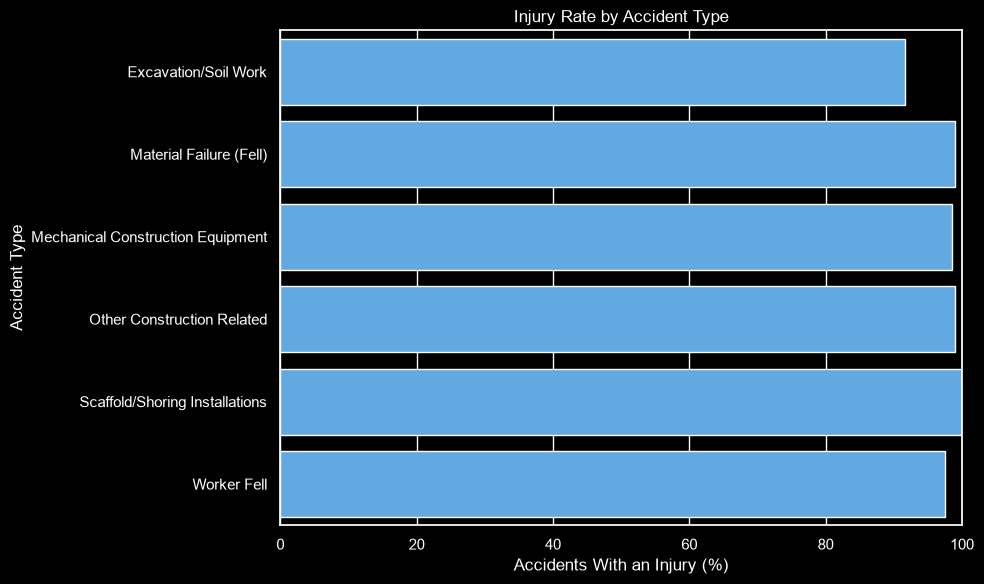

In [22]:
ax = sea.barplot(
    data=injury_rate,
    x='Had Injury',
    y='Check2 Description',
    color=accent_color
)
ax.set(
    title='Injury Rate by Accident Type',
    xlabel='Accidents With an Injury (%)',
    ylabel='Accident Type',
    xlim=(0, 100)
)
ax.figure.set_size_inches(10, 6)
ax.figure.tight_layout()

## Total injuries and fatalities by accident type

In [23]:
harm_by_type = accidents.groupby('Check2 Description')[
    ['Injury', 'Fatality']
].sum()

harm_by_type

,Injury,Fatality
Check2 Description,,
Excavation/Soil Work,12,2
Material Failure (Fell),99,1
Mechanical Construction Equipment,77,2
Other Construction Related,286,3
Scaffold/Shoring Installations,19,0
Worker Fell,483,12


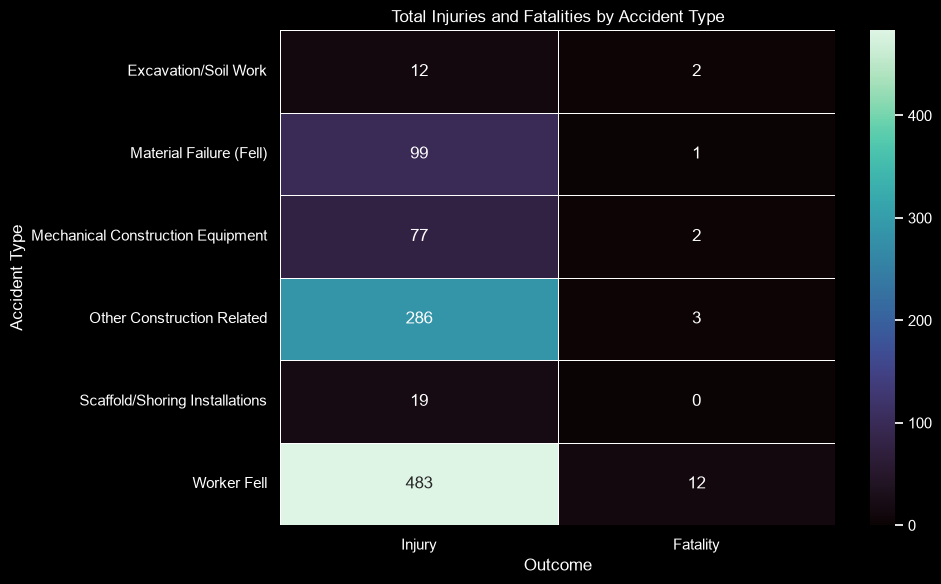

In [24]:
ax = sea.heatmap(
    harm_by_type,
    annot=True,
    fmt='g',
    cmap='mako',
    linewidths=0.5
)
ax.set(
    title='Total Injuries and Fatalities by Accident Type',
    xlabel='Outcome',
    ylabel='Accident Type'
)
ax.figure.set_size_inches(10, 6)
ax.figure.tight_layout()

## Results

The main issue is that falls cause the most harm to construction workers. Based on the data, construction sites should require fall-protection equipment, such as harnesses, and provide better employee safety training. These measures should help reduce injuries and fatalities.